## Name: (double click cell and replace this text with your name)


# Data Filtering and Computational Chemistry (5 pts)

**Instructions:**  You are allowed to use any Jupyter Notebooks and/or Gemini to help you do this assignment; however, keep in mind that ***we will be disabling Gemini during lab and you will not have Gemini on any quizzes or exams (but you will have your lab notebook as these quizzes/exams are open notebook).*** Therefore, you should take the time to try to understand the general syntax while doing these assignments by taking notes in your lab notebooks as you've done previously. All concept check interactive quizzes are ungraded and have unlimited attempts.


In [ ]:
# @title Overview
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>

<style>
div.alert {
    color: #0056b3;
    background-color: #d9edf7;
    border-left: 5px solid #31708f;
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
}
div.alert ul {
    margin: 0.5em 0;
}
div.alert li {
    margin-bottom: 0.5em;
}
</style>

<div class="alert alert-block alert-info">
  <p> <strong> Overview: </strong> </p>
  <ul>
    <li> Slice subsets of data from NumPy arrays and pandas DataFrames </li>
    <li> Filter data using Boolean masks and conditional logic </li>
    <li> Apply simple smoothing techniques (rolling average and convolution) </li>
    <li> Run electronic structure calculations using PSI4 </li>
  </ul>
</div>

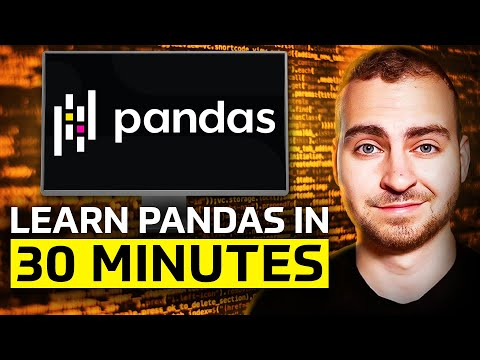

In [ ]:
#@title YouTube - Python
#@markdown Start at DataFrame fundamentals (2:05)
from IPython.display import YouTubeVideo
YouTubeVideo("EXIgjIBu4EU",width=640,height=360)

In [ ]:
# @title Import Packages
# @markdown Hit the play button once to import relevant packages for this assignment
%%capture
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14

#Quizzes
from IPython.display import display, HTML

%pip install "jupyterquiz"
from jupyterquiz import display_quiz

#Import quizzes and rotation1.json from GitHub
!wget https://raw.githubusercontent.com/prajay-patel/CHE-3131/main/Rotation-3-Thermodynamics/rotation3.json
!wget https://raw.githubusercontent.com/prajay-patel/CHE-3131/main/Rotation-3-Thermodynamics/Sample-Data/PreLab_SampleData.xlsx
!wget https://raw.githubusercontent.com/prajay-patel/CHE-3131/main/quiz_utils.py

import quiz_utils

## Part 1: Review of Data Slicing

In this section, you’ll practice slicing arrays and DataFrames to review indexing techniques.

In [ ]:
# @title Note
%%html

 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>

<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">

<p> <b> What is Data Slicing?</b>

<ul>
    <li><strong>Slicing</strong> means selecting a smaller portion of data from a list, NumPy array, or pandas DataFrame.</li>
    <li><strong>Basic syntax:</strong> <code>data[start:end]</code> → includes elements from <code>start</code> up to (but not including) <code>end</code>.</li>
    <li>You can omit parts:
      <ul>
        <li><code>data[:5]</code> → from the beginning</li>
        <li><code>data[5:]</code> → to the end</li>
        <li><code>data[:]</code> → all elements</li>
      </ul>
    </li>
    <li>Add a <strong>step</strong> to skip elements: <code>data[::2]</code> → every second element.</li>
    <li>Use <strong>negative indices</strong> to count from the end: <code>data[-3:]</code> → last three elements.</li>
    <li>In <strong>NumPy arrays</strong>, slicing works the same but supports multiple dimensions, e.g. <code>arr[0:3, 1:4]</code>.</li>
    <li>In <strong>pandas</strong>:
      <ul>
        <li><code>.iloc[]</code> → position-based (row/column numbers)</li>
        <li><code>.loc[]</code> → label- or condition-based (e.g., <code>df.loc[df['time'] &gt; 5]</code>)</li>
      </ul>
    </li>
    <li><strong>Remember:</strong> the <code>end</code> index is <em>exclusive</em>, so <code>data[0:5]</code> gives elements <code>0–4</code>.</li>
  </ul>

    <div style="margin-top:8px; padding:8px; background:#f7f7f9; border-left:4px solid #e1e1e8;">
    <strong>Quick examples</strong>
    <pre style="margin:6px 0; font-size:13px;">
    x = [10, 20, 30, 40, 50]
    x[1:4]  → [20, 30, 40]
    x[::2]  → [10, 30, 50]
    x[-2:]  → [40, 50]
    </pre>
  </div>
</div>

### 1.1 Array Slicing (1 pt)

In [ ]:
# Create a NumPy array with 101 numbers evenly spaced from 0 to 10
x = np.linspace(0, 10, 101)

# Let's look at it
print(x)

[ 0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2  1.3
  1.4  1.5  1.6  1.7  1.8  1.9  2.   2.1  2.2  2.3  2.4  2.5  2.6  2.7
  2.8  2.9  3.   3.1  3.2  3.3  3.4  3.5  3.6  3.7  3.8  3.9  4.   4.1
  4.2  4.3  4.4  4.5  4.6  4.7  4.8  4.9  5.   5.1  5.2  5.3  5.4  5.5
  5.6  5.7  5.8  5.9  6.   6.1  6.2  6.3  6.4  6.5  6.6  6.7  6.8  6.9
  7.   7.1  7.2  7.3  7.4  7.5  7.6  7.7  7.8  7.9  8.   8.1  8.2  8.3
  8.4  8.5  8.6  8.7  8.8  8.9  9.   9.1  9.2  9.3  9.4  9.5  9.6  9.7
  9.8  9.9 10. ]


In [ ]:
# @title Exercise: Practice Data Slicing
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>


<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p> <strong> Exercise: </strong> Code the following data slicing filters irrespctive of the size of the list:
<ul>
<li> The first 10 elements</li>
<li> The last 5 elements</li>
<li> Every 4 elements</li>
</ul>

</div>


In [ ]:
# Populate the list of an arbitrary number of points (between 10-1000) evenly spaced between 0 and 100
random.seed(42) # Generates the seed of random value (guarantees the same randomly generated number)
x = np.linspace(0,100,np.random.randint(10,1000))

# Get the first 10 elements of list
first_10 = x[:10]

# Get the last 5 elements irrepsective of length of list
last_5 = x[-5:]

# Get every 4th element of list
every_4th = x[::4]

print("First 10:", first_10)
print("Last 5:", last_5)
print("Every 5th:", every_4th)

First 10: [ 0.     3.125  6.25   9.375 12.5   15.625 18.75  21.875 25.    28.125]
Last 5: [ 87.5    90.625  93.75   96.875 100.   ]
Every 5th: [  0.   12.5  25.   37.5  50.   62.5  75.   87.5 100. ]


### 1.2 DataFrame Slicing

You purchased a "frictionless" cow that operates like a pendulum from the internet, you try it out, but something doesn't seem right. So you plot its motion over 10 oscillations using a camera, and some image recognition software. The result is a little noisy:

<div>
  <center> <img height="300" src="https://github.com/prajay-patel/CHE-3131/blob/main/Rotation-3-Thermodynamics/Figures/PreLab_Pendulum.png?raw=True"> </center>
</div>

In [ ]:
# @title Exercise: Proving your case (2 pts)
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>


<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p> <strong> Exercise: </strong> You are writing an email to their customer service department
and you need proof that your "frictionless pendulum" is losing amplitude!
To do this, you will need to do the following:
<ul>
  <li> Filter the dataframe in three sections:</li>
<ul>
<li> The first oscillation (0-2 seconds)</li>
<li> The fifth oscillation (10-12 seconds)</li>
<li> The last oscillation (18-20 seconds)</li>
</ul>
<li> Then, you will calculate the mean and standard deviation of each section.</li>
<li> Finally, you will create an errorbar plot of the filtered data for the three sets.</li>
</div>


### Filtering Data with Conditions in pandas

In **pandas**, you can filter rows by applying **logical conditions** to your DataFrame columns.  
This returns only the rows that meet those conditions.

---

#### Basic Concept

- A condition such as `df['signal'] > 0` produces a **Series** of `True`/`False` values — one for each row.  
- You can use that Series inside square brackets to select the matching rows:

```python
df_filtered = df[df['signal'] > 0]
```
---

### Combining Multiple Conditions:
-   Use & for AND
-   Use | for OR
-  Always wrap each condition in parentheses
```python
df_filtered = df[(df['signal'] < 0) & (df['time'] > 8)]
```

---

### Convenient Methods:
- `df['time'].between(2, 8)` selects rows where time is between 2 and 8
- `df['category'].isin(['A', 'B'])` selects rows matching specific categories

In [ ]:
# View the sample data for this plot
pos_df=pd.read_excel('PreLab_SampleData.xlsx',sheet_name='Sheet1',index_col=0)
pos_df

,time,position
0,0.00,0.100751
1,0.02,0.150210
2,0.04,0.227135
3,0.06,0.659826
4,0.08,0.772896
...,...,...
996,19.92,-0.846508
997,19.94,-0.615840
998,19.96,-0.438908
999,19.98,0.076118


In [ ]:
# Code the correct logical condition to filter all time measurements under 2 seconds inclusive
first_osc = pos_df.loc[pos_df['time'] <= 2]
first_osc

,time,position
0,0.00,0.100751
1,0.02,0.150210
2,0.04,0.227135
3,0.06,0.659826
4,0.08,0.772896
...,...,...
96,1.92,-0.816450
97,1.94,-0.442799
98,1.96,-0.200764
99,1.98,-0.281744


In [ ]:
# Code the correct logical condition to filter all time measurements between 10-12 seconds inclusive
fifth_osc = pos_df[pos_df['time'].between(10,12)]
fifth_osc

,time,position
500,10.00,-0.178340
501,10.02,0.405070
502,10.04,0.599930
503,10.06,0.460348
504,10.08,1.061895
...,...,...
596,11.92,-0.270964
597,11.94,-0.444278
598,11.96,-0.337534
599,11.98,-0.186266


Note to Instructor:

```python
pos_df[(pos_df['time']>=10) & (pos_df['time']<=12)]
```

is an alternative way to use the conditions to select the same time window.

In [ ]:
# Code the correct logical condition to filter all time measurements between 18-20 seconds inclusive
last_osc = pos_df.loc[pos_df['time'] >= 18]
last_osc

,time,position
900,18.00,0.349740
901,18.02,0.252624
902,18.04,0.470603
903,18.06,0.659044
904,18.08,0.571604
...,...,...
996,19.92,-0.846508
997,19.94,-0.615840
998,19.96,-0.438908
999,19.98,0.076118


In [ ]:
# Calculate the mean and standard deviation of each oscillation
first_mean=first_osc['position'].mean()
first_err=first_osc['position'].std(ddof=1)

fifth_mean=fifth_osc['position'].mean()
fifth_err=fifth_osc['position'].std(ddof=1)

last_mean=last_osc['position'].mean()
last_err=last_osc['position'].std(ddof=1)

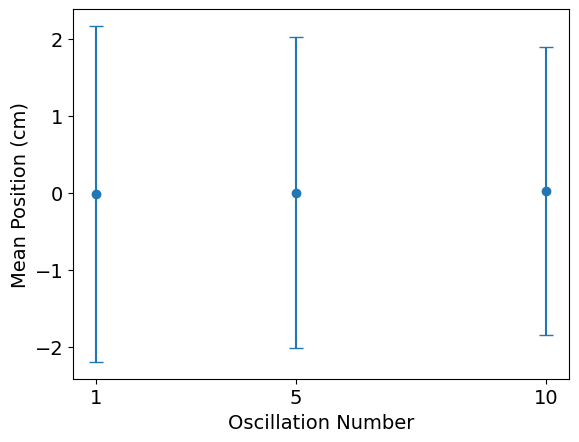

In [ ]:
# Create an errorbar plot
oscillation_numbers = [1, 5, 10] # Representing the 1st, 5th, and 10th oscillations
means = [first_mean, fifth_mean, last_mean]
errors = [first_err, fifth_err, last_err]

# Create the errorbar plot for the oscillation data
plt.errorbar(oscillation_numbers, means, yerr=errors, fmt='o', capsize=5)
plt.xlabel("Oscillation Number")
plt.ylabel("Mean Position (cm)")
plt.xticks(oscillation_numbers)
plt.show()

In [ ]:
# @title Question 1
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>

<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
div.gold-note ul {
    margin: 0.5em 0; /* Space around the list */
}
div.gold-note li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="gold-note">

<p> <strong> Question: </strong> Based on your errorbar plot,
do you have a convincing argument against the "frictionless" pendulum?
</div>


---

**ANSWER GOES HERE**

<font color='red'> This is a conclusive argument since the standard deviation, which effectively represents the amplitude in this example, decreases as a function of time. This can be seen as the appropriate y error bars.

---

In [ ]:
# @title Question 2
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>

<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
div.gold-note ul {
    margin: 0.5em 0; /* Space around the list */
}
div.gold-note li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="gold-note">

<p> <strong> Question: </strong> What other aspects of this pendulum
data can be filtered to provide further analysis?
</div>


---

**ANSWER GOES HERE**

<font color='red'> The other two second intervals can be filtered to create a clearer visual of the decreasing amplitude based on the decreasing standard deviation. A plot of the standard deviation as a function of time may also work.

---

### 1.3 Moving averages


In [ ]:
# @title Note
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>

<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">
<p> <strong> Note: </strong>
A moving average calculates the average over a specified range and
then propagates that average as it increases in index.
</div>


In [ ]:
# @title Exercise: Moving/Rolling Averages (1 pt)
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>


<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p> <strong> Exercise: </strong>
Would a moving average help your case? Try calculating a moving (or rolling)
average of 250 points of the position DataFrame (pos_df).</div>

In [ ]:
# Run the code below to understand rolling averages
x = pd.DataFrame([0,0,0,1,1,1,2,2,2])
y = x.rolling(3).mean()
y

,0
0,NaN
1,NaN
2,0.000000
3,0.333333
4,0.666667
5,1.000000
6,1.333333
7,1.666667
8,2.000000


In [ ]:
# @title Question 3
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>

<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
div.gold-note ul {
    margin: 0.5em 0; /* Space around the list */
}
div.gold-note li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="gold-note">
<p> <strong> Question: </strong> </p>
What does the code in the cell above do? What is the output and what does it mean?
</div>

---

**ANSWER GOES HERE**

<font color='red'> A rolling average (or moving average) smooths out fluctuations in data by taking the average of a fixed number of consecutive data points as the window “rolls” forward through the dataset. For each new position of the window, the oldest value is dropped, and the newest value is added, producing a sequence of averaged values that reveal trends more clearly by reducing noise.

<font color='red'> This particular rolling average rolls every 3 consecutive data points and computes the average. Because the first two points do not have three preceding points, the values are reported as Not-a-Number (or NaN).

---

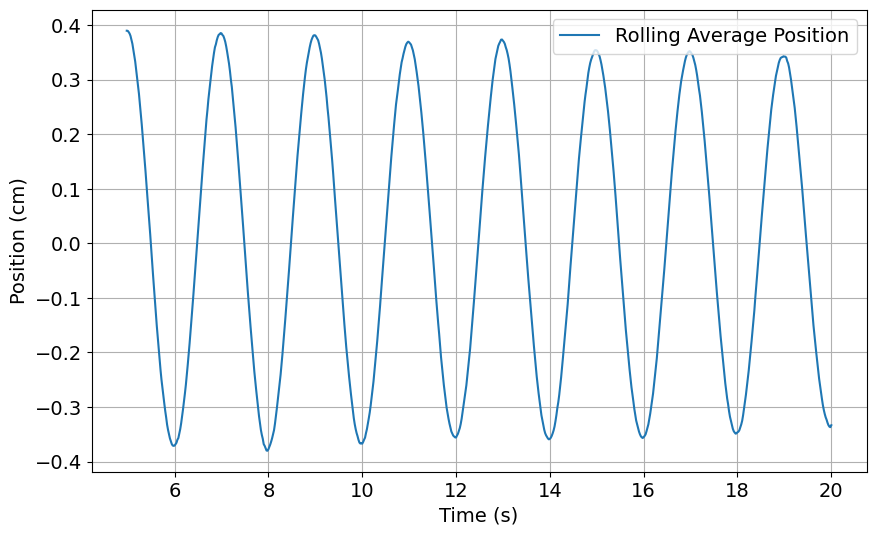

In [ ]:
# Calculate the rolling average of pos_df['position']

rolling_avg_position = pos_df['position'].rolling(250).mean()

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(pos_df['time'], rolling_avg_position, label='Rolling Average Position')
plt.xlabel("Time (s)")
plt.ylabel("Position (cm)")
plt.legend()
plt.grid(True)
plt.show()

## Part 2: Calculating thermodynamic values using computational chemistry

In physical chemistry, we often want to connect **molecular structure** with **observable properties** like reaction energies, spectra, or heat capacities. Electronic structure programs such as **ORCA**, **Gaussian**, or **PSI4** do this by numerically solving the **Schrödinger equation** for molecules.

- **Inputs:**  
  - Atom types
  - XYZ coordinates
  - choice of quantum mechanical method (e.g., Hartree–Fock, DFT)
  - basis set (e.g., cc-pVTZ, def2-TZVP).

- **Outputs:**  
  - Optimized molecular geometries  
  - Electronic energies  
  - Molecular orbitals  
  - Vibrational frequencies and thermodynamic properties

The program uses quantum mechanics to determine the electronic energy and force constants of a molecule. From the force constants (via vibrational frequencies), we apply **statistical thermodynamics** to predict macroscopic properties like $C_p$, $C_v$, $\Delta H$, $\Delta S$, and $\Delta G$.  


In [ ]:
#@title **Install Conda Colab**
#@markdown It will restart the kernel (session), don't worry.
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:14
🔁 Restarting kernel...


In [ ]:
#@title **Create PSI4 environment**
#@markdown We will be using an electronic structure code called PSI4 to compute thermodynamic properties
%%capture
import subprocess
import sys
subprocess.run("rm -rf /usr/local/conda-meta/pinned", shell=True)
subprocess.run("mamba create -n psi4_env psi4 -c conda-forge/label/psi4_dev", shell=True)

In [ ]:
#@title Compute thermodynamic properties for $Ar$ and $N_2$

%%bash
# Import packages
source activate psi4_env
python
import psi4
import os
import sys
import numpy as np
import multiprocessing
import time

# Start the run
start_time = time.time()

# Set the geometry for Ar
mol_Ar = psi4.geometry("""
0 1
Ar 0.0 0.0 0.0
""")
psi4.core.set_output_file('optfreq_output_Ar.out', False)
psi4.frequency('pbe0/cc-pvtz', molecule=mol_Ar, return_wfn=True) # Calculate the thermo properties at the PBE0/cc-pVTZ level of theory

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Calculation Time for Ar: {elapsed_time} seconds")

# Repeat for N2
start_time = time.time()

# Set the initial geometry for N2
mol_N2 = psi4.geometry("""
0 1
N 0.0 0.0 -0.549
N 0.0 0.0 0.549
""")
psi4.core.set_output_file('optfreq_output_N2.out', False)

# Run an optimization and frequency calculation (PBE0/cc-pVTZ)
psi4.optimize('pbe0/cc-pvtz', molecule=mol_N2)
psi4.frequency('pbe0/cc-pvtz', molecule=mol_N2, return_wfn=True)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Calculation Time for N2: {elapsed_time} seconds")

Calculation Time for Ar: 4.4664506912231445 seconds
Optimizer: Optimization complete!
Calculation Time for N2: 16.9836528301239 seconds


Some dependencies such as QCElemental have not yet finished migration to pydantic v2. If issues are encountered please downgrade pydantic or upgrade QCElemental as appropriate


In [ ]:
# @title Exercise: Text extraction (1 pt)
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>


<style>
div.orange-alert {
    color: #854f00; /* Darker shade of orange for text */
    background-color: #ffe6cc; /* Light orange background */
    border-left: 5px solid #ff9933; /* Bright orange border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
}
div.orange-alert ul {
    margin: 0.5em 0; /* Space around the list */
}
div.orange-alert li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="orange-alert">
<p> <strong> Exercise: </strong>
The code below will open the output files you just generated in Python.
Find the phrase <b>Total G, Gibbs energy</b>,
which is the absolute Gibbs energy
(not to be confused with a Gibbs free energy of formation).
</div>

In [ ]:
with open('optfreq_output_Ar.out') as f:
  lines = f.readlines()

lines

['\n',
 '         ----------------------------------------------------------\n',
 '                                   FINDIF\n',
 '                     R. A. King and Jonathon Misiewicz\n',
 '         ----------------------------------------------------------\n',
 '\n',
 '  Using finite-differences of gradients to determine vibrational frequencies and \n',
 '  normal modes. Resulting frequencies are only valid at stationary points.\n',
 '    Generating geometries for use with 3-point formula.\n',
 '    Displacement size will be 5.00e-03.\n',
 '    Number of atoms is 1.\n',
 '    Number of irreps is 8.\n',
 '    Number of SALCs is 0.\n',
 '    Translations projected? 1. Rotations projected? 0.\n',
 '    Index of SALCs per irrep:\n',
 '      1 : \n',
 '      2 : \n',
 '      3 : \n',
 '      4 : \n',
 '      5 : \n',
 '      6 : \n',
 '      7 : \n',
 '      8 : \n',
 '    Number of SALCs per irrep:\n',
 '      Irrep 1: 0\n',
 '      Irrep 2: 0\n',
 '      Irrep 3: 0\n',
 '      Irrep 4:

In [ ]:
with open('optfreq_output_N2.out') as f2:
  lines2 = f2.readlines()

lines2

['\n',
 'Scratch directory: /tmp/\n',
 'gradient() will perform analytic gradient computation.\n',
 '   => Libint2 <=\n',
 '\n',
 '    Primary   basis highest AM E, G, H:  6, 6, 3\n',
 '    Auxiliary basis highest AM E, G, H:  7, 7, 4\n',
 '    Onebody   basis highest AM E, G, H:  -, -, -\n',
 '    Solid Harmonics ordering:            Gaussian\n',
 '\n',
 '*** tstart() called on 4f125c5b2ebd\n',
 '*** at Fri Aug  1 19:45:25 2025\n',
 '\n',
 '   => Loading Basis Set <=\n',
 '\n',
 '    Name: CC-PVTZ\n',
 '    Role: ORBITAL\n',
 '    Keyword: BASIS\n',
 '    atoms 1-2 entry N          line   224 file /usr/local/envs/psi4_env/share/psi4/basis/cc-pvtz.gbs \n',
 '\n',
 '\n',
 '         ---------------------------------------------------------\n',
 '                                   SCF\n',
 '               by Justin Turney, Rob Parrish, Andy Simmonett\n',
 '                          and Daniel G. A. Smith\n',
 '                              RKS Reference\n',
 '                        1 Thr

In [ ]:
# A blank cell if you decide to use Python to extract the text from these files





In [ ]:
# @title Question 4
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>

<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
div.gold-note ul {
    margin: 0.5em 0; /* Space around the list */
}
div.gold-note li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="gold-note">
<p> <strong> Question: </strong> </p>
Search through the output files and report the <b>Total Energy</b>
for \( Ar \) and \( N_2 \), respectively, in the answer block below.
Comment on how you did this.
<ul>
  <li> Did you use a text search function/command
     (CTRL+F, grep, regular expressions, etc.)? </li>
  <li> Did you manually search for it? </li>
</ul>
</div>

---

**ANSWER GOES HERE**

<font color='red'> Ar = -527.39640573 Eh, N2 = -109.45421306 Eh (note some of the decimal places will be different based on SCF convergence criteria and numerical precision)

<font color='red'> For these files, a simple looking through the file or using CTRL+F will suffice. In the main module, there are a few hundred text files that will require using a loop to efficiently extract all the relevant information. People familiar with bash may opt to use 'grep' to find the phrase.

---


In [ ]:
# @title Question 5
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>

<style>
div.gold-note {
    color: #796748; /* Dark gold for text */
    background-color: #F7F0E2; /* Light cream/gold background */
    border-left: 5px solid #D8B266; /* Medium gold accent border */
    padding: 0.5em;
    font-size: 1.25em;
    line-height: 1.5;
    font-family: Arial, sans-serif;
}
div.gold-note ul {
    margin: 0.5em 0; /* Space around the list */
}
div.gold-note li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="gold-note">
<p> <strong> Question: </strong> </p>
What coding technique(s) can assist with text extraction if we are dealing with hundreds of text files?
</div>

---

**ANSWER GOES HERE**

<font color='red'> Looping structures (for loops) involving getting regular expressions (grep).

---


In [ ]:
# @title Note
%%html
 <head>
    <!-- See http://docs.mathjax.org/en/latest/web/start.html#using-mathjax-from-a-content-delivery-network-cdn -->
    <script type="text/javascript" id="MathJax-script" async
        src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js">
    </script>
  </head>

<style>
div.purple-box {
    color: #4b0082; /* Indigo for text */
    background-color: #f3e5f5; /* Light lavender background */
    border-left: 5px solid #7b1fa2; /* Medium purple border */
    padding: 0.5em;
    font-size: 1.25em; /* Matches the surrounding text size */
    line-height: 1.5; /* Ensures readability */
    font-family: Arial, sans-serif; /* Clean, modern font */
}
div.purple-box ul {
    margin: 0.5em 0; /* Space around the list */
}
div.purple-box li {
    margin-bottom: 0.5em; /* Space between list items */
}
</style>

<div class="purple-box">
<p> <strong> Note: </strong> </p>
Download the output files (<strong>optfreq_output_Ar.out</strong>,
<strong>optfreq_output_N2.out</strong>).

You will need these files for the analysis part in lab.
</div>